# Video Emotion Recognition Model Training Pipeline

## Configuration

### Imports

**Note:** For RetinaFace with TensorFlow 2.16+: **Restart kernel** and **Run All** from the top so `TF_USE_LEGACY_KERAS` takes effect before TensorFlow loads.

**Preprocessing progress:** install **`tqdm`** for ETA bars (`pip install tqdm`). If missing, preprocessing still runs without progress bars.

In [1]:
import os
# Must be set BEFORE any TensorFlow import - fixes KerasTensor compatibility with RetinaFace on TF 2.16+
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import cv2
import numpy as np
# Import TensorFlow FIRST so it loads with legacy Keras, then RetinaFace will use it
import tensorflow as tf
from retinaface import RetinaFace
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path

import sys
print(f"Python: {sys.executable}")
print(f"TensorFlow: {tf.__version__}")
print("GPUs:", tf.config.list_physical_devices("GPU"))


2026-04-18 07:57:48.330782: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-18 07:57:49.052005: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Python: /home/yousef/Scenolytics/tf-gpu/bin/python
TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Global Variables

In [2]:
# Paths
VIDEOS_DIR = os.path.abspath('./../Datasets/Video')

# Use a separate folder so you don't mix the full dataset with the actor subset
ACTOR_START_INDEX = 23  # Skip 1-23, start from actor 24 (0-based: 23 = Actor_24)
ACTOR_LIMIT = None      # None = use all from 24 to end (24, 25, ..., 47/48)
PREPROCESSED_DIR = f'./preprocessed_data_actors'

# CREMA-D and RAF-DB dataset paths (folders named after datasets)
CREMA_D_DIR = os.path.abspath('./../Datasets/CREMA-D')
RAF_DB_DIR = os.path.abspath('./../Datasets/RAF-DB')

MODEL_SAVE_PATH = './models/best_video_emotion_model.h5'

# Emotion mapping
EMOTIONS = {
    "01": "neutral", "02": "calm", "03": "happy", "04": "sad",
    "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised"
}
EMOTION_TO_IDX = {emotion: idx for idx, emotion in enumerate(EMOTIONS.values())}
NUM_EMOTIONS_CLASSES = len(EMOTIONS)

# RAVDESS: actors 25-48 are duplicates of 1-24; map to 1-24 for correct actor-disjoint split
RAVDESS_NUM_UNIQUE_ACTORS = 24

# Video preprocessing
FRAMES_PER_VIDEO = 10  # Reduced from 20 for faster processing and less overfitting
IMG_SIZE = 160  # Reduced from 224 for faster processing
FRAME_RATE = 10

# Model architecture
# Backbone: 'efficientnet_b0' (recommended) or 'resnet50' (legacy)
BACKBONE = 'efficientnet_b0'
BACKBONE_TRAINABLE_LAST = 20  # fewer unfrozen layers to reduce overfitting
LSTM_UNITS = 128  # Increased for better capacity (was 64)
LSTM_LAYERS = 2  # Back to 2 layers as requested
DROPOUT_RATE = 0.5  # Stronger regularization (train/val gap)

# Training
BATCH_SIZE = 16  # Increased from 8 for faster training
EPOCHS = 50  # Reduced from 80
LEARNING_RATE = 5e-5  # lower LR with stronger reg / LSTM stability
PATIENCE = 15  # Reduced from 25


### Multi-dataset preprocessing (RAVDESS + CREMA-D + RAF-DB)

After **Frames Extraction**, run **`preprocess_all_datasets_with_actors()`** to build `.npy` files and **`metadata_with_actors.pkl`** for all three sources.

Dataset paths live in **Global Variables** above.


## Pre-Processing

In [3]:
# RAVDESS helpers + load unified metadata (RAVDESS / CREMA-D / RAF-DB)

def parse_actor_id_from_ravdess_filename(filename: str) -> int:
    """Parse actor ID (01-24, 25-48, etc.) from a RAVDESS-style filename.
    RAVDESS actors 25-48 are duplicates of 1-24; use ravdess_actor_to_identity() for splits.
    """
    base = os.path.basename(filename)
    parts = base.split('-')
    if len(parts) < 7:
        raise ValueError(f"Unexpected RAVDESS filename format: {filename}")
    actor_part = parts[-1]
    actor_str = os.path.splitext(actor_part)[0]
    return int(actor_str)


def ravdess_actor_to_identity(actor_id: int) -> int:
    """Map RAVDESS actor ID to unique identity 1..24 (actors 25-48 are duplicates of 1-24)."""
    n = RAVDESS_NUM_UNIQUE_ACTORS if 'RAVDESS_NUM_UNIQUE_ACTORS' in globals() else 24
    return ((actor_id - 1) % n) + 1


def load_preprocessed_metadata_with_actors():
    """Load actor-aware metadata and return (file_paths, labels, actor_ids).

    Expects PREPROCESSED_DIR/metadata_with_actors.pkl created by
    preprocess_all_datasets_with_actors().
    Metadata items are stored like: (npy_path, emotion_idx, emotion_name, actor_id).
    """
    metadata_path = os.path.join(PREPROCESSED_DIR, 'metadata_with_actors.pkl')

    if not os.path.exists(metadata_path):
        raise FileNotFoundError(
            f"Preprocessed actor-aware metadata not found at {metadata_path}. "
            "Run preprocess_all_datasets_with_actors() first."
        )

    with open(metadata_path, 'rb') as f:
        metadata = pickle.load(f)

    file_paths = [item[0] for item in metadata]
    labels = [item[1] for item in metadata]
    actor_ids = [item[3] for item in metadata]
    # Support extended format (path, emotion_idx, emotion_name, actor_id, dataset_id)
    if len(metadata) > 0 and len(metadata[0]) >= 5:
        dataset_ids = [item[4] for item in metadata]
    else:
        dataset_ids = ['RAVDESS'] * len(file_paths)

    return file_paths, labels, actor_ids, dataset_ids


### Face detection

In [4]:
def detect_and_crop_face(frame):
    """Detect and crop face from frame using RetinaFace"""
    RGB_Frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    Faces = RetinaFace.detect_faces(RGB_Frame)
    
    if isinstance(Faces, dict) and len(Faces) > 0:
        First_Face = next(iter(Faces.values()))
        Facial_Area = First_Face["facial_area"]
        x1, y1, x2, y2 = Facial_Area
        # Add padding
        padding = 20
        x1 = max(0, x1 - padding)
        y1 = max(0, y1 - padding)
        x2 = min(frame.shape[1], x2 + padding)
        y2 = min(frame.shape[0], y2 + padding)
        
        face = frame[y1:y2, x1:x2]
        return face
    
    return frame

### Frames Extraction

In [5]:
def extract_frames_from_video(video_path, num_frames=16, target_size=(224, 224)):
    """Extract evenly spaced frames from video"""
    Cap = cv2.VideoCapture(video_path)
    Total_Frames = int(Cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    if Total_Frames < num_frames:
        Frame_Indices = np.linspace(0, Total_Frames - 1, num_frames, dtype=int)
    else:
        Frame_Indices = np.linspace(0, Total_Frames - 1, num_frames, dtype=int)
    
    Frames = []
    for i in Frame_Indices:
        Cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        IsReturned, Frame = Cap.read()
        
        if IsReturned:
            Frame = detect_and_crop_face(Frame)
            Frame = cv2.resize(Frame, target_size)
            Frame = cv2.cvtColor(Frame, cv2.COLOR_BGR2RGB)
            Frames.append(Frame)
        else:
            if Frames:
                Frames.append(Frames[-1])
            else:
                Frames.append(np.zeros((target_size[0], target_size[1], 3)))
    
    Cap.release()
    return np.array(Frames)


### Unified preprocessing (`.npy` + `metadata_with_actors.pkl`)

Progress bars use **`tqdm`** (ETA like Keras training). Install if needed: `pip install tqdm`.

In [6]:
try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable, desc=None, total=None, unit=None, **kwargs):
        return iterable

import time

# --- CREMA-D and RAF-DB: emotion maps and unified preprocessing ---

# CREMA-D filename emotion codes -> our 8 emotions (CREMA-D has no calm/surprised)
CREMA_D_EMOTION_MAP = {
    'ANG': 'angry', 'DIS': 'disgust', 'FEA': 'fearful',
    'HAP': 'happy', 'NEU': 'neutral', 'SAD': 'sad',
}

# RAF-DB basic 7 classes (index 0-6) -> our emotion names (RAF-DB has no calm)
# Order: Surprise, Fear, Disgust, Happiness, Sadness, Anger, Neutral
RAF_DB_IDX_TO_EMOTION = {
    0: 'surprised', 1: 'fearful', 2: 'disgust', 3: 'happy',
    4: 'sad', 5: 'angry', 6: 'neutral',
}


def _preprocess_crema_d(all_metadata, video_count):
    """Process CREMA-D videos from CREMA_D_DIR. Appends to all_metadata, returns new video_count."""
    if not os.path.isdir(CREMA_D_DIR):
        print(f"CREMA-D dir not found: {CREMA_D_DIR} (skipping)")
        return all_metadata, video_count
    # Look for VideoFlash or root-level video files
    video_root = os.path.join(CREMA_D_DIR, 'VideoFlash') if os.path.isdir(os.path.join(CREMA_D_DIR, 'VideoFlash')) else CREMA_D_DIR
    if not os.path.isdir(video_root):
        print(f"CREMA-D video folder not found: {video_root} (skipping)")
        return all_metadata, video_count
    exts = ('.flv', '.mp4', '.avi')
    files = [f for f in os.listdir(video_root) if f.lower().endswith(exts)]
    print(f"CREMA-D: found {len(files)} videos in {video_root}")
    for idx, f in tqdm(enumerate(files), total=len(files), desc="CREMA-D", unit="vid"):
        try:
            parts = f.replace('.flv', '').replace('.mp4', '').replace('.avi', '').split('_')
            if len(parts) < 3:
                continue
            actor_id = int(parts[0][:4])  # first 4 digits
            emo_code = parts[2].upper()
            emotion_name = CREMA_D_EMOTION_MAP.get(emo_code)
            if emotion_name is None:
                continue
            emotion_idx = EMOTION_TO_IDX[emotion_name]
            path = os.path.join(video_root, f)
            frames = extract_frames_from_video(path, num_frames=FRAMES_PER_VIDEO, target_size=(IMG_SIZE, IMG_SIZE))
            frames = frames.astype(np.float32) / 255.0
            save_path = os.path.join(PREPROCESSED_DIR, f"crema_{video_count:05d}.npy")
            np.save(save_path, frames)
            all_metadata.append((save_path, emotion_idx, emotion_name, actor_id, 'CREMA-D'))
            video_count += 1
        except Exception:
            continue
    return all_metadata, video_count


def _preprocess_raf_db(all_metadata, video_count):
    """Process RAF-DB images: load, face crop, tile to FRAMES_PER_VIDEO, save. Appends to all_metadata."""
    import glob as _glob

    if not os.path.isdir(RAF_DB_DIR):
        print(f"RAF-DB dir not found: {RAF_DB_DIR} (skipping)")
        return all_metadata, video_count

    print(f"\nRAF-DB: resolving labels and images under {RAF_DB_DIR!r}")

    # --- Find list_partition_label.txt (recursive glob + common layouts) ---
    tried_patterns = []
    label_matches = []
    rel_patterns = [
        "list_partition_label.txt",
        "list_patition_label.txt",
        "EmoLabel/list_partition_label.txt",
        "basic/list_partition_label.txt",
        "basic/EmoLabel/list_partition_label.txt",
        "**/list_partition_label.txt",
        "**/list_patition_label.txt",
    ]
    for rp in rel_patterns:
        pat = os.path.join(RAF_DB_DIR, rp)
        tried_patterns.append(pat)
        label_matches.extend(_glob.glob(pat, recursive=True))

    seen = []
    for p in sorted(set(os.path.normpath(x) for x in label_matches)):
        if os.path.isfile(p) and p not in seen:
            seen.append(p)

    print("RAF-DB: glob patterns tried for label file:")
    for tp in tried_patterns:
        print(f"    {tp}")
    print("RAF-DB: label file matches found:")
    if not seen:
        print("    (none) — RAF-DB will be skipped")
    else:
        for p in seen:
            print(f"    {p}")

    label_file = seen[0] if seen else None
    if label_file is None:
        print("RAF-DB: no list_partition_label.txt — skipping.")
        return all_metadata, video_count

    print(f"RAF-DB: using label file: {label_file}")

    # --- Image roots: fixed list + discover **/Image and **/aligned ---
    _subs = [
        "",
        "Image",
        "Image/original",
        "Image/aligned",
        "basic",
        "basic/Image",
        "basic/Image/original",
        "basic/Image/aligned",
        "train",
        "test",
        "original",
        "aligned",
    ]
    image_roots = []
    print("RAF-DB: image directory candidates:")
    for sub in _subs:
        d = os.path.normpath(os.path.join(RAF_DB_DIR, sub) if sub else RAF_DB_DIR)
        if os.path.isdir(d):
            if d not in image_roots:
                image_roots.append(d)
                print(f"    [ok] {d}")
        else:
            print(f"    [missing] {d}")

    for extra in _glob.glob(os.path.join(RAF_DB_DIR, "**", "Image"), recursive=True):
        extra = os.path.normpath(extra)
        if os.path.isdir(extra) and extra not in image_roots:
            image_roots.append(extra)
            print(f"    [discovered] {extra}")
    for extra in _glob.glob(os.path.join(RAF_DB_DIR, "**", "aligned"), recursive=True):
        extra = os.path.normpath(extra)
        if os.path.isdir(extra) and extra not in image_roots:
            image_roots.append(extra)
            print(f"    [discovered] {extra}")

    label_dir = os.path.dirname(os.path.abspath(label_file))

    def _resolve_raf_image(fname):
        if not fname:
            return None
        if os.path.isabs(fname) and os.path.isfile(fname):
            return fname
        trials = []
        for root in image_roots:
            trials.append(os.path.join(root, fname))
            trials.append(os.path.join(root, os.path.basename(fname)))
        trials.append(os.path.join(RAF_DB_DIR, fname))
        trials.append(os.path.join(label_dir, fname))
        trials.append(os.path.join(label_dir, os.path.basename(fname)))
        for t in trials:
            t = os.path.normpath(t)
            if os.path.isfile(t):
                return t
        return None

    rows = []
    n_missing = 0
    missing_samples = []
    with open(label_file, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) >= 3:
                partition, fname, label_idx = int(parts[0]), parts[1], int(parts[2])
            elif len(parts) == 2:
                fname, label_idx = parts[0], int(parts[1])
                partition = 0
            else:
                continue
            if label_idx > 6:
                label_idx = label_idx - 1
            if label_idx not in RAF_DB_IDX_TO_EMOTION:
                continue
            emotion_name = RAF_DB_IDX_TO_EMOTION[label_idx]
            emotion_idx = EMOTION_TO_IDX[emotion_name]
            img_path = _resolve_raf_image(fname)
            if img_path is None:
                n_missing += 1
                if len(missing_samples) < 15:
                    missing_samples.append(fname)
                continue
            rows.append((img_path, emotion_idx, emotion_name, partition, fname))

    print(f"RAF-DB: {len(rows)} images with resolved paths ({n_missing} partition rows skipped — file not found)")
    if missing_samples:
        print(f"RAF-DB: sample missing filenames (first {len(missing_samples)}): {missing_samples!r}")

    for (img_path, emotion_idx, emotion_name, partition, fname) in tqdm(
        rows, total=len(rows), desc="RAF-DB", unit="img"
    ):
        try:
            frame = cv2.imread(img_path)
            if frame is None:
                continue
            frame = detect_and_crop_face(frame)
            frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = frame.astype(np.float32) / 255.0
            frames = np.tile(frame[np.newaxis, ...], (FRAMES_PER_VIDEO, 1, 1, 1))
            save_path = os.path.join(PREPROCESSED_DIR, f"raf_{video_count:05d}.npy")
            np.save(save_path, frames)
            pseudo_actor = partition * 1000 + (hash(fname) % 100)
            all_metadata.append((save_path, emotion_idx, emotion_name, pseudo_actor, "RAF-DB"))
            video_count += 1
        except Exception:
            continue
    return all_metadata, video_count


def preprocess_all_datasets_with_actors():
    """Run RAVDESS + CREMA-D + RAF-DB and save unified metadata_with_actors.pkl (5-tuple with dataset_id)."""
    _t_preprocess_start = time.perf_counter()
    Path(PREPROCESSED_DIR).mkdir(parents=True, exist_ok=True)
    all_metadata = []
    video_count = 0

    # 1) RAVDESS (same logic as preprocess_and_save_dataset_with_actors but append dataset_id)
    all_actors = [a for a in sorted(os.listdir(VIDEOS_DIR)) if os.path.isdir(os.path.join(VIDEOS_DIR, a))]
    start = ACTOR_START_INDEX if 'ACTOR_START_INDEX' in globals() else 0
    limit = ACTOR_LIMIT if ACTOR_LIMIT is not None else len(all_actors) - start
    selected = all_actors[start:start + limit]
    print("RAVDESS:", len(selected), "actor folders")
    rav_tasks = []
    for Actor in selected:
        Actor_Path = os.path.join(VIDEOS_DIR, Actor)
        if not os.path.isdir(Actor_Path):
            continue
        for Video_File in [f for f in os.listdir(Actor_Path) if f.lower().endswith(".mp4")]:
            rav_tasks.append((Actor, Actor_Path, Video_File))
    for Actor, Actor_Path, Video_File in tqdm(rav_tasks, desc="RAVDESS", unit="vid"):
        try:
            parts = Video_File.split('-')
            if len(parts) < 3:
                continue
            emotion_name = EMOTIONS.get(parts[2])
            if emotion_name is None:
                continue
            emotion_idx = EMOTION_TO_IDX[emotion_name]
            actor_id = parse_actor_id_from_ravdess_filename(Video_File)
            actor_id = ravdess_actor_to_identity(actor_id)
            frames = extract_frames_from_video(
                os.path.join(Actor_Path, Video_File),
                num_frames=FRAMES_PER_VIDEO, target_size=(IMG_SIZE, IMG_SIZE))
            frames = frames.astype(np.float32) / 255.0
            save_path = os.path.join(PREPROCESSED_DIR, f"video_{video_count:05d}.npy")
            np.save(save_path, frames)
            all_metadata.append((save_path, emotion_idx, emotion_name, actor_id, 'RAVDESS'))
            video_count += 1
        except Exception:
            continue

    # 2) CREMA-D
    all_metadata, video_count = _preprocess_crema_d(all_metadata, video_count)

    # 3) RAF-DB
    all_metadata, video_count = _preprocess_raf_db(all_metadata, video_count)

    metadata_path = os.path.join(PREPROCESSED_DIR, 'metadata_with_actors.pkl')
    with open(metadata_path, 'wb') as f:
        pickle.dump(all_metadata, f)
    print("Unified metadata saved to", metadata_path, "| total samples:", len(all_metadata))
    from collections import Counter
    emotion_counts = Counter(item[1] for item in all_metadata)
    for label in sorted(emotion_counts.keys()):
        print(f"  {list(EMOTIONS.values())[label]}: {emotion_counts[label]}")
    _elapsed = time.perf_counter() - _t_preprocess_start
    print(f"\nPreprocessing wall time: {_elapsed/60:.1f} min ({_elapsed:.0f} s)")

    return all_metadata


## Data Augmentation & Batch Processing

In [7]:
def augment_frame(frame):
    """Apply random augmentations to frame"""
    # Random horizontal flip
    if np.random.random() > 0.5:
        frame = cv2.flip(frame, 1)
    
    # Random brightness adjustment
    brightness_factor = np.random.uniform(0.6, 1.4)  # Wider range
    frame = np.clip(frame * brightness_factor, 0, 1)
    
    # Random contrast adjustment
    contrast_factor = np.random.uniform(0.7, 1.3)  # Wider range
    mean = frame.mean()
    frame = np.clip((frame - mean) * contrast_factor + mean, 0, 1)
    
    # Random saturation adjustment
    hsv = cv2.cvtColor((frame * 255).astype(np.uint8), cv2.COLOR_RGB2HSV).astype(np.float32) / 255.0
    saturation_factor = np.random.uniform(0.8, 1.2)
    hsv[:, :, 1] = np.clip(hsv[:, :, 1] * saturation_factor, 0, 1)
    frame = cv2.cvtColor((hsv * 255).astype(np.uint8), cv2.COLOR_HSV2RGB).astype(np.float32) / 255.0
    
    # Small random rotation (-20 to +20 degrees)
    angle = np.random.uniform(-20, 20)
    h, w = frame.shape[:2]
    M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
    frame = cv2.warpAffine(frame, M, (w, h), borderMode=cv2.BORDER_REFLECT)
    
    # Random zoom (0.9 to 1.1)
    zoom_factor = np.random.uniform(0.9, 1.1)
    h, w = frame.shape[:2]
    new_h, new_w = int(h * zoom_factor), int(w * zoom_factor)
    frame = cv2.resize(frame, (new_w, new_h))
    if zoom_factor > 1:
        # Crop center
        start_h = (new_h - h) // 2
        start_w = (new_w - w) // 2
        frame = frame[start_h:start_h+h, start_w:start_w+w]
    else:
        # Pad
        pad_h = (h - new_h) // 2
        pad_w = (w - new_w) // 2
        frame = cv2.copyMakeBorder(frame, pad_h, h - new_h - pad_h, pad_w, w - new_w - pad_w, cv2.BORDER_REFLECT)
    
    # Mild Gaussian noise (robustness to compression / sensor noise)
    if np.random.random() > 0.5:
        noise = np.random.normal(0, 0.02, frame.shape).astype(np.float32)
        frame = np.clip(frame + noise, 0, 1)
    
    return frame

## Model Building & Training

### Building

Architecture: <br>
    1. EfficientNet-B0 or ResNet50 (ImageNet pre-trained) per frame <br>
    2. Bi-LSTM processes temporal sequence <br>
    3. Attention mechanism focuses on important frames <br>
    4. Classification head <br>

In [8]:
@tf.keras.utils.register_keras_serializable(package="Custom", name="SumPooling")
class SumPooling(layers.Layer):
    """Sum over time axis (default 1). Serializable replacement for Lambda + reduce_sum."""

    def __init__(self, axis=1, **kwargs):
        super().__init__(**kwargs)
        self.axis = axis

    def call(self, inputs):
        return tf.reduce_sum(inputs, axis=self.axis)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"axis": self.axis})
        return cfg


def build_model():
    """Build CNN-LSTM model with attention (backbone from BACKBONE global)."""
    bb = str(BACKBONE).lower().replace('-', '_') if 'BACKBONE' in globals() else 'efficientnet_b0'
    print(f"Building model (backbone={bb})...")
    
    tf.keras.backend.clear_session()
    
    Model_Input_Layer = layers.Input(shape=(FRAMES_PER_VIDEO, IMG_SIZE, IMG_SIZE, 3))

    if bb == 'resnet50':
        Base_CNN = ResNet50(
            include_top=False,
            weights='imagenet',
            input_shape=(IMG_SIZE, IMG_SIZE, 3),
            pooling='avg'
        )
        for Layer in Base_CNN.layers[:-10]:
            Layer.trainable = False
    else:
        Base_CNN = EfficientNetB0(
            include_top=False,
            weights='imagenet',
            input_shape=(IMG_SIZE, IMG_SIZE, 3),
            pooling='avg'
        )
        n_last = BACKBONE_TRAINABLE_LAST if 'BACKBONE_TRAINABLE_LAST' in globals() else 40
        n_last = min(n_last, len(Base_CNN.layers))
        for i, layer in enumerate(Base_CNN.layers):
            layer.trainable = (i >= len(Base_CNN.layers) - n_last)
    
    CNN_Features = layers.TimeDistributed(Base_CNN)(Model_Input_Layer)
    CNN_Features = layers.GaussianNoise(0.1)(CNN_Features)
    CNN_Features = layers.Dropout(DROPOUT_RATE)(CNN_Features)
    
    LSTM_Out = layers.Bidirectional(
        layers.LSTM(LSTM_UNITS, return_sequences=True, dropout=DROPOUT_RATE,
                   recurrent_dropout=DROPOUT_RATE,
                   kernel_regularizer=regularizers.l2(0.001))
    )(CNN_Features)
    
    LSTM_Out = layers.Bidirectional(
        layers.LSTM(LSTM_UNITS, return_sequences=True, dropout=DROPOUT_RATE,
                   recurrent_dropout=DROPOUT_RATE,
                   kernel_regularizer=regularizers.l2(0.001))
    )(LSTM_Out)
    
    # Attention Mechanism
    Attention_Layer = layers.Dense(1, activation='tanh')(LSTM_Out)
    Attention_Layer = layers.Flatten()(Attention_Layer)
    Attention_Layer = layers.Activation('softmax')(Attention_Layer)
    Attention_Layer = layers.RepeatVector(2 * LSTM_UNITS)(Attention_Layer)
    Attention_Layer = layers.Permute([2, 1])(Attention_Layer)
    
    attended = layers.Multiply()([LSTM_Out, Attention_Layer])

    # Reduce over time dimension (tf.keras only)
    attended = SumPooling(axis=1)(attended)
    
    # Classification Head
    x = layers.Dense(256, activation='relu',  # Reduced from 512
                    kernel_regularizer=regularizers.l2(0.001))(attended)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(DROPOUT_RATE)(x)
    
    x = layers.Dense(128, activation='relu',  # Reduced from 256
                    kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(DROPOUT_RATE)(x)
    
    Model_Output_Layer = layers.Dense(NUM_EMOTIONS_CLASSES, activation='softmax')(x)
    
    Model = tf.keras.Model(
        inputs=Model_Input_Layer,
        outputs=Model_Output_Layer,
        name='Video_Emotion_Recognition',
    )
    Model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=1.0),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=[
            'accuracy',
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name='top_2_accuracy'),
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name='top_3_accuracy')  # Added top-3
        ]
    )
    
    return Model


### Training

In [9]:
# Data generator (loads preprocessed .npy frame sequences)
import numpy as np
import tensorflow as tf


def normalize_video_frames_for_backbone(frames):
    """Preprocess frames for the active BACKBONE. Input: float RGB in [0, 1]."""
    bb = str(BACKBONE).lower().replace('-', '_') if 'BACKBONE' in globals() else 'efficientnet_b0'
    x = frames.astype(np.float32)
    if bb == 'resnet50':
        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
        return (x - mean) / std
    from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_pi
    return effnet_pi(np.clip(x * 255.0, 0.0, 255.0))


class VideoDataGenerator(tf.keras.utils.Sequence):
    """Keras Sequence for video emotion data stored as .npy arrays.

    Each .npy is expected to be shape: (FRAMES_PER_VIDEO, IMG_SIZE, IMG_SIZE, 3)
    and already normalized to [0, 1] (as saved by preprocess_and_save_dataset()).
    """

    def __init__(self, file_paths, labels, batch_size=16, shuffle=True, augment=False):
        self.file_paths = list(file_paths)
        self.labels = np.array(labels)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.file_paths) / self.batch_size))

    def __getitem__(self, index):
        batch_indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        batch_paths = [self.file_paths[i] for i in batch_indices]
        batch_labels = self.labels[batch_indices]

        batch_videos = []
        for path in batch_paths:
            frames = np.load(path).astype(np.float32)
            if self.augment and 'augment_frame' in globals():
                frames = np.array([augment_frame(frame) for frame in frames])
            frames = normalize_video_frames_for_backbone(frames)
            batch_videos.append(frames)

        return np.array(batch_videos), batch_labels

    def on_epoch_end(self):
        self.indices = np.arange(len(self.file_paths))
        if self.shuffle:
            np.random.shuffle(self.indices)


In [10]:
def train_model_actor_disjoint():
    """Train the model using an actor-disjoint train/val/test split.

    Uses metadata produced by preprocess_all_datasets_with_actors(), i.e.
    PREPROCESSED_DIR/metadata_with_actors.pkl with entries
    (npy_path, emotion_idx, emotion_name, actor_id).
    """
    print("=" * 80)
    print("LOADING PREPROCESSED ACTOR-AWARE DATA")
    print("=" * 80)

    # Load actor-aware metadata (returns dataset_ids when from preprocess_all_datasets_with_actors)
    result = load_preprocessed_metadata_with_actors()
    file_paths, labels, actor_ids = result[0], result[1], result[2]
    dataset_ids = result[3] if len(result) >= 4 else ['RAVDESS'] * len(file_paths)
    labels = np.array(labels)
    actor_ids = np.array(actor_ids)
    dataset_ids = np.array(dataset_ids)

    print(f"Loaded {len(file_paths)} preprocessed samples")
    for ds in np.unique(dataset_ids):
        n = np.sum(dataset_ids == ds)
        print(f"  {ds}: {n}")

    # Build train/val/test indices: actor-disjoint for RAVDESS and CREMA-D, random for RAF-DB
    idx_train, idx_val, idx_test = [], [], []
    for ds in np.unique(dataset_ids):
        mask = dataset_ids == ds
        inds = np.where(mask)[0]
        d_actors = actor_ids[mask]
        unique_actors = np.unique(d_actors)
        if len(unique_actors) >= 3 and ds in ('RAVDESS', 'CREMA-D'):
            # Actor-disjoint split
            a_train, a_temp = train_test_split(unique_actors, test_size=0.4, random_state=42, shuffle=True)
            a_val, a_test = train_test_split(a_temp, test_size=0.5, random_state=42, shuffle=True)
            for i in inds:
                if actor_ids[i] in a_train:
                    idx_train.append(i)
                elif actor_ids[i] in a_val:
                    idx_val.append(i)
                else:
                    idx_test.append(i)
        else:
            # Random split (e.g. RAF-DB or single-actor)
            i_tr, i_rest = train_test_split(inds, test_size=0.4, random_state=42, stratify=labels[mask])
            i_va, i_te = train_test_split(i_rest, test_size=0.5, random_state=42, stratify=labels[i_rest])
            idx_train.extend(i_tr)
            idx_val.extend(i_va)
            idx_test.extend(i_te)

    idx_train = np.array(idx_train)
    idx_val = np.array(idx_val)
    idx_test = np.array(idx_test)

    file_paths_train = [file_paths[i] for i in idx_train]
    file_paths_val = [file_paths[i] for i in idx_val]
    file_paths_test = [file_paths[i] for i in idx_test]

    labels_train = labels[idx_train]
    labels_val = labels[idx_val]
    labels_test = labels[idx_test]

    print("\nDataset split (train / val / test):")
    print(f"  Train: {len(file_paths_train)} samples")
    print(f"  Val:   {len(file_paths_val)} samples")
    print(f"  Test:  {len(file_paths_test)} samples")

    # Compute class weights on training labels only
    classes_unique = np.unique(labels_train)
    class_weights_arr = compute_class_weight(
        class_weight='balanced',
        classes=classes_unique,
        y=labels_train,
    )
    # Map each true label id to its weight (avoid index mismatch when some
    # classes are missing from the current training subset)
    Class_Weights = {int(c): w for c, w in zip(classes_unique, class_weights_arr)}
    # Keras expects keys 0..num_classes-1; fill missing classes with weight 1.0
    num_classes = NUM_EMOTIONS_CLASSES if 'NUM_EMOTIONS_CLASSES' in globals() else 8
    Class_Weights = {i: Class_Weights.get(i, 1.0) for i in range(num_classes)}
    # Boost recall on harder classes (on top of balanced weights)
    if 'EMOTION_TO_IDX' in globals():
        for emo_name, mult in (('sad', 1.5), ('angry', 1.3), ('fearful', 1.2)):
            ei = EMOTION_TO_IDX.get(emo_name)
            if ei is not None and ei in Class_Weights:
                Class_Weights[ei] = float(Class_Weights[ei]) * mult
        print("Class-weight boosts (sad×1.5, angry×1.3, fearful×1.2) applied on balanced weights.")

    # Create data generators
    train_gen = VideoDataGenerator(
        file_paths_train,
        labels_train,
        batch_size=BATCH_SIZE,
        shuffle=True,
        augment=True,
    )
    val_gen = VideoDataGenerator(
        file_paths_val,
        labels_val,
        batch_size=BATCH_SIZE,
        shuffle=False,
    )
    test_gen = VideoDataGenerator(
        file_paths_test,
        labels_test,
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

    # Build model
    model = build_model()
    print("\n" + "=" * 80)
    print("MODEL ARCHITECTURE")
    print("=" * 80)
    model.summary()

    # Callbacks
    Path('./models').mkdir(exist_ok=True)
    print(
        f"\nEarlyStopping patience: {PATIENCE} epochs "
        f"(monitors val_top_2_accuracy; waits {PATIENCE} epochs without improvement)"
    )
    print(
        "ReduceLROnPlateau patience: 5 epochs (reduces learning rate, "
        "does NOT stop training)\n"
    )

    callbacks = [
        ModelCheckpoint(
            MODEL_SAVE_PATH,
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1,
        ),
        EarlyStopping(
            monitor='val_top_2_accuracy',
            mode='max',
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1,
        ),
    ]

    # Train
    print("\n" + "=" * 80)
    print("TRAINING (actor-disjoint)")
    print("=" * 80)

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS,
        callbacks=callbacks,
        class_weight=Class_Weights,
        verbose=1,
    )

    return model, history, test_gen, labels_test


## Evaluation & Visualization

In [11]:
def evaluate_model(model, test_gen, labels_test):
    """Evaluate model on test set; save report and print top confusion pairs."""
    print("\n" + "=" * 80)
    print("EVALUATION")
    print("=" * 80)

    predictions = model.predict(test_gen, verbose=1)
    predicted_classes = np.argmax(predictions, axis=1)

    emotion_names = list(EMOTIONS.values())
    num_c = NUM_EMOTIONS_CLASSES if "NUM_EMOTIONS_CLASSES" in globals() else len(emotion_names)
    label_ids = np.arange(num_c)

    report_str = classification_report(
        labels_test,
        predicted_classes,
        labels=label_ids,
        target_names=emotion_names,
        zero_division=0,
    )
    print("\nClassification Report:")
    print(report_str)

    Path("./models").mkdir(parents=True, exist_ok=True)
    rep_path = "./models/classification_report.txt"
    with open(rep_path, "w", encoding="utf-8") as f:
        f.write(report_str)
    print(f"\nClassification report saved to {rep_path}")

    cm = confusion_matrix(labels_test, predicted_classes, labels=label_ids)

    pairs = []
    for i in range(num_c):
        for j in range(num_c):
            if i != j and cm[i, j] > 0:
                pairs.append((int(cm[i, j]), i, j))
    pairs.sort(key=lambda x: -x[0])
    print("\nTop confusion pairs (true → predicted, count):")
    for count, i, j in pairs[:12]:
        print(f"  {emotion_names[i]} → {emotion_names[j]}: {count}")

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=emotion_names,
        yticklabels=emotion_names,
    )
    plt.title("Confusion Matrix")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig("./models/confusion_matrix.png", dpi=300, bbox_inches="tight")
    print(f"Confusion matrix figure saved to ./models/confusion_matrix.png")
    plt.show()

    print("\nPer-Class Accuracy (support > 0):")
    for i in label_ids:
        row_sum = cm[i].sum()
        if row_sum > 0:
            print(f"  {emotion_names[i]}: {cm[i, i] / row_sum:.2%}")


def plot_training_history(history):
    """Plot training curves"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].plot(history.history["accuracy"], label="Train Accuracy")
    axes[0].plot(history.history["val_accuracy"], label="Val Accuracy")
    axes[0].set_title("Model Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history.history["loss"], label="Train Loss")
    axes[1].plot(history.history["val_loss"], label="Val Loss")
    axes[1].set_title("Model Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig("./models/training_history.png", dpi=300, bbox_inches="tight")
    plt.show()


## Main Execution

Use **Run All** from the top. The code cell below runs the full pipeline:

1. Clears the Keras session and optionally configures GPU
2. Runs `preprocess_all_datasets_with_actors()` if `metadata_with_actors.pkl` is missing under `PREPROCESSED_DIR`, or if you set `FORCE_PREPROCESS = True`
3. Trains with `train_model_actor_disjoint()` (actor-disjoint splits) then `evaluate_model()` and training plots

To re-preprocess from scratch, delete the preprocessed folder or set `FORCE_PREPROCESS = True`.


Checking GPU availability...
Found 1 GPU(s)
GPU configured.
Running preprocess_all_datasets_with_actors() ...
RAVDESS: 24 actor folders


RAVDESS:   0%|          | 0/2878 [00:00<?, ?vid/s]

I0000 00:00:1774178841.521038   27164 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3537 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9
2026-03-22 13:27:24.468147: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-03-22 13:27:38.321967: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.12GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


CREMA-D: found 7442 videos in /home/yousef/Scenolytics/Datasets/CREMA-D


CREMA-D:   0%|          | 0/7442 [00:00<?, ?vid/s]

2026-03-22 15:10:36.238982: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.12GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.



RAF-DB: resolving labels and images under '/home/yousef/Scenolytics/Datasets/RAF-DB'
RAF-DB: glob patterns tried for label file:
    /home/yousef/Scenolytics/Datasets/RAF-DB/list_partition_label.txt
    /home/yousef/Scenolytics/Datasets/RAF-DB/list_patition_label.txt
    /home/yousef/Scenolytics/Datasets/RAF-DB/EmoLabel/list_partition_label.txt
    /home/yousef/Scenolytics/Datasets/RAF-DB/basic/list_partition_label.txt
    /home/yousef/Scenolytics/Datasets/RAF-DB/basic/EmoLabel/list_partition_label.txt
    /home/yousef/Scenolytics/Datasets/RAF-DB/**/list_partition_label.txt
    /home/yousef/Scenolytics/Datasets/RAF-DB/**/list_patition_label.txt
RAF-DB: label file matches found:
    (none) — RAF-DB will be skipped
RAF-DB: no list_partition_label.txt — skipping.
Unified metadata saved to ./preprocessed_data_actors/metadata_with_actors.pkl | total samples: 10320
  neutral: 1279
  calm: 384
  happy: 1655
  sad: 1655
  angry: 1654
  fearful: 1655
  disgust: 1654
  surprised: 384

Preproces

E0000 00:00:1774195660.422969   27164 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inVideo_Emotion_Recognition/time_distributed/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-03-22 18:07:49.578068: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f5932016360 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-22 18:07:49.578415: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-03-22 18:07:49.628282: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774195669.984886   27204 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


381/381 [==============================] - ETA: 0s - loss: 6.0217 - accuracy: 0.1423 - top_2_accuracy: 0.2768 - top_3_accuracy: 0.4042
Epoch 1: val_accuracy improved from -inf to 0.16618, saving model to ./models/best_video_emotion_model.h5
381/381 [==============================] - 299s 730ms/step - loss: 6.0217 - accuracy: 0.1423 - top_2_accuracy: 0.2768 - top_3_accuracy: 0.4042 - val_loss: 4.7475 - val_accuracy: 0.1662 - val_top_2_accuracy: 0.3343 - val_top_3_accuracy: 0.5212 - lr: 5.0000e-05
Epoch 2/50
381/381 [==============================] - ETA: 0s - loss: 5.6712 - accuracy: 0.1736 - top_2_accuracy: 0.3270 - top_3_accuracy: 0.4628
Epoch 2: val_accuracy improved from 0.16618 to 0.26590, saving model to ./models/best_video_emotion_model.h5
381/381 [==============================] - 240s 629ms/step - loss: 5.6712 - accuracy: 0.1736 - top_2_accuracy: 0.3270 - top_3_accuracy: 0.4628 - val_loss: 4.4909 - val_accuracy: 0.2659 - val_top_2_accuracy: 0.4566 - val_top_3_accuracy: 0.6281 -

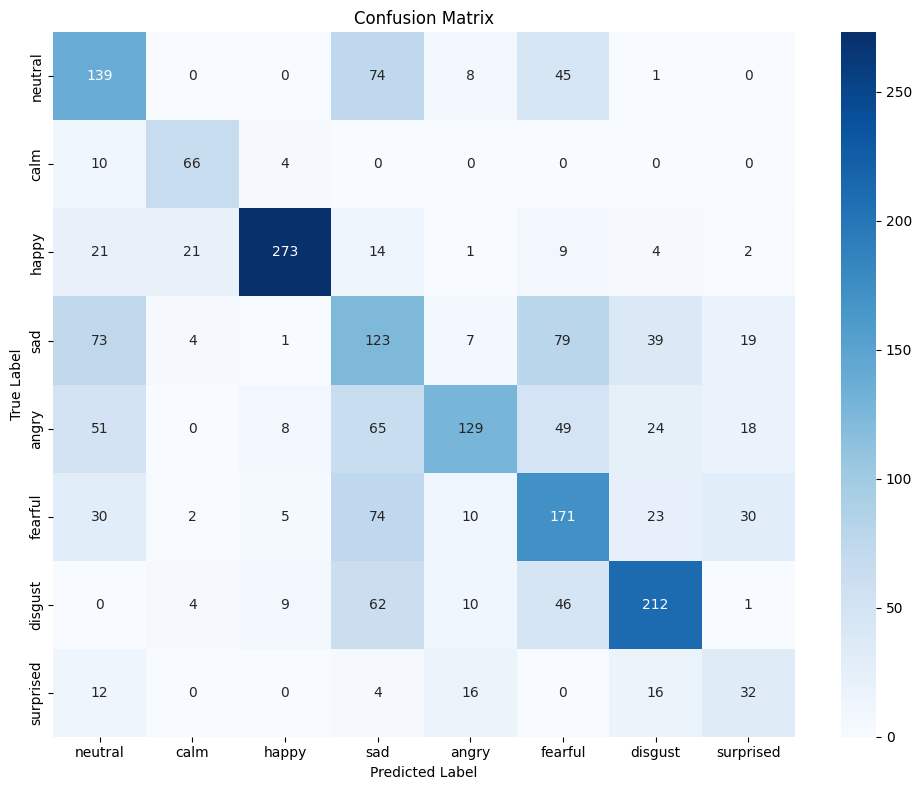


Per-Class Accuracy (support > 0):
  neutral: 52.06%
  calm: 82.50%
  happy: 79.13%
  sad: 35.65%
  angry: 37.50%
  fearful: 49.57%
  disgust: 61.63%
  surprised: 40.00%


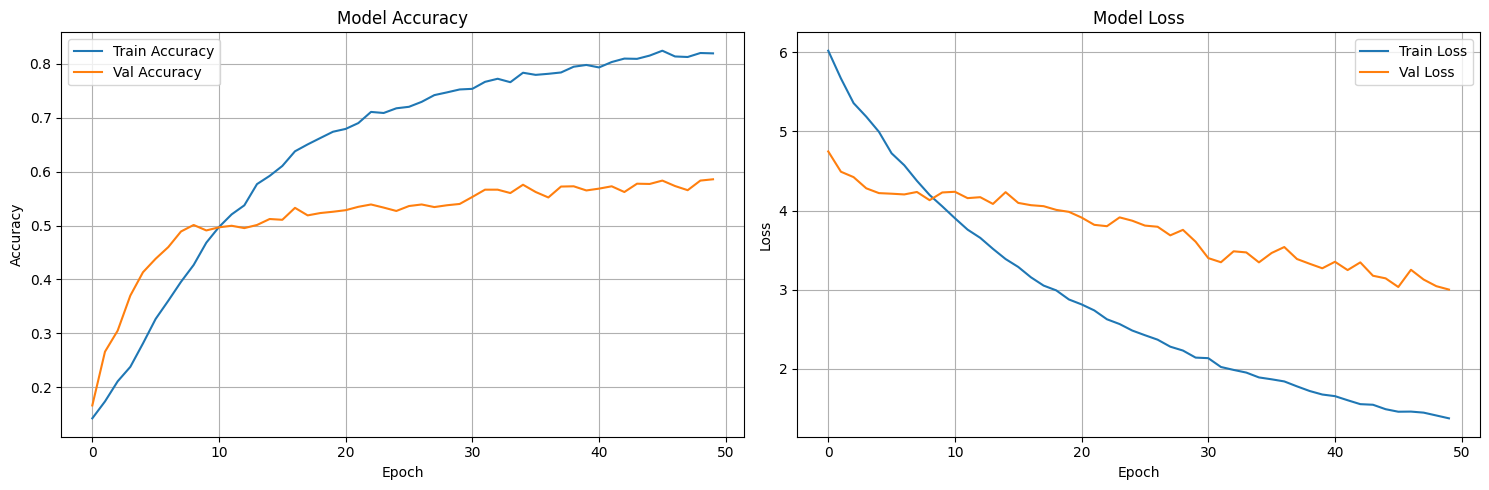


COMPLETE — actor-disjoint video emotion training


In [12]:
# Clear session; optional CUDA paths for WSL (only if folders exist)
import os
_libs = ['/usr/lib/wsl/lib', '/usr/local/cuda-12.3/targets/x86_64-linux/lib']
_extra = ':'.join(p for p in _libs if os.path.isdir(p))
if _extra:
    os.environ['LD_LIBRARY_PATH'] = _extra + ':' + os.environ.get('LD_LIBRARY_PATH', '')

import tensorflow as tf
tf.keras.backend.clear_session()
import gc
gc.collect()

print("Checking GPU availability...")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"Found {len(gpus)} GPU(s)")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    tf.config.set_visible_devices(gpus[0], 'GPU')
    print("GPU configured.")
else:
    print("No GPU — training will use CPU (slower).")

# --- Full pipeline: preprocess (if needed) → train → evaluate ---
META_ACTORS = os.path.join(PREPROCESSED_DIR, 'metadata_with_actors.pkl')
FORCE_PREPROCESS = False  # set True to rebuild .npys and metadata

if FORCE_PREPROCESS or not os.path.isfile(META_ACTORS):
    print("Running preprocess_all_datasets_with_actors() ...")
    preprocess_all_datasets_with_actors()
else:
    print(f"Found {META_ACTORS} — skipping preprocessing.")
    print("Set FORCE_PREPROCESS = True in this cell to re-run preprocessing.\n")

model, history, test_gen, labels_test = train_model_actor_disjoint()
evaluate_model(model, test_gen, labels_test)
if callable(globals().get('plot_training_history')):
    plot_training_history(history)

print("\n" + "=" * 80)
print("COMPLETE — actor-disjoint video emotion training")
print("=" * 80)


## Data Balance Checking

In [13]:
def check_data_balance(show_plot=True):
    """
    Check if the dataset is balanced across emotion classes
    """
    import pickle
    from collections import Counter
    import matplotlib.pyplot as plt
    import numpy as np
    
    print("="*80)
    print("DATA BALANCE ANALYSIS")
    print("="*80)
    
    # Load metadata
    metadata_path = os.path.join(PREPROCESSED_DIR, 'metadata_with_actors.pkl')
    
    if not os.path.exists(metadata_path):
        print("❌ No preprocessed data found. Run preprocessing first!")
        return
    
    with open(metadata_path, 'rb') as f:
        metadata = pickle.load(f)
    
    # Extract labels
    labels = [item[1] for item in metadata]
    emotion_names_list = list(EMOTIONS.values())
    
    # Count emotions
    emotion_counts = Counter(labels)
    total_videos = len(labels)
    
    print(f"\n📊 Total videos: {total_videos}")
    print(f"📊 Number of emotion classes: {len(emotion_counts)}")
    print("\n" + "-"*60)
    print(f"{'Emotion':<15} {'Count':<10} {'Percentage':<12} {'Balance'}")
    print("-"*60)
    
    # Calculate statistics
    counts = []
    for label in sorted(emotion_counts.keys()):
        emotion = emotion_names_list[label]
        count = emotion_counts[label]
        percentage = (count / total_videos) * 100
        counts.append(count)
        
        # Determine balance status
        if percentage > 15:  # More than 15% for 8 classes
            balance = "✅ Over-represented"
        elif percentage < 10:  # Less than 10% for 8 classes
            balance = "⚠️  Under-represented"
        else:
            balance = "✓ Balanced"
        
        print(f"{emotion:<15} {count:<10} {percentage:>6.2f}%      {balance}")
    
    print("-"*60)
    
    # Statistical analysis
    counts_array = np.array(counts)
    mean_count = np.mean(counts_array)
    std_count = np.std(counts_array)
    min_count = np.min(counts_array)
    max_count = np.max(counts_array)
    imbalance_ratio = max_count / min_count if min_count > 0 else float('inf')
    
    print(f"\n📈 Statistical Summary:")
    print(f"   Mean samples per class: {mean_count:.2f}")
    print(f"   Std deviation: {std_count:.2f}")
    print(f"   Min samples: {min_count}")
    print(f"   Max samples: {max_count}")
    print(f"   Imbalance ratio (max/min): {imbalance_ratio:.2f}")
    
    # Interpretation
    print(f"\n💡 Interpretation:")
    if imbalance_ratio <= 1.5:
        print("   ✅ Dataset is WELL BALANCED (ratio ≤ 1.5)")
        print("   → No special handling needed")
    elif imbalance_ratio <= 3.0:
        print("   ⚠️  Dataset is MODERATELY IMBALANCED (1.5 < ratio ≤ 3.0)")
        print("   → Using class weights (already implemented) is recommended")
    else:
        print("   ❌ Dataset is HIGHLY IMBALANCED (ratio > 3.0)")
        print("   → Consider data augmentation or advanced techniques")
    
    print("="*80)
    
    # Visualization
    if show_plot:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # Bar plot
        emotions = [emotion_names_list[label] for label in sorted(emotion_counts.keys())]
        counts_list = [emotion_counts[label] for label in sorted(emotion_counts.keys())]
        colors = plt.cm.Set3(np.linspace(0, 1, len(emotions)))
        
        bars = ax1.bar(emotions, counts_list, color=colors, edgecolor='black', linewidth=1.5)
        ax1.axhline(y=mean_count, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_count:.0f}')
        ax1.set_xlabel('Emotion', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Number of Videos', fontsize=12, fontweight='bold')
        ax1.set_title('Emotion Distribution (Bar Plot)', fontsize=14, fontweight='bold')
        ax1.tick_params(axis='x', rotation=45)
        ax1.legend()
        ax1.grid(axis='y', alpha=0.3)
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        # Pie chart
        ax2.pie(counts_list, labels=emotions, autopct='%1.1f%%', 
                colors=colors, startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})
        ax2.set_title('Emotion Distribution (Pie Chart)', fontsize=14, fontweight='bold')
        
        plt.tight_layout()
        
        # Save plot
        plot_path = os.path.join(PREPROCESSED_DIR, 'data_balance_analysis.png')
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        print(f"\n💾 Plot saved to: {plot_path}")
        plt.show()
    
    return emotion_counts

# Optional: run after preprocessing — check_data_balance(show_plot=True)


## GUI: Video emotion by 10-second segments

Upload a video to get **per-segment** predictions (every 10 seconds), **percentage per emotion** across the video, and **overall emotion with confidence**.

In [14]:
# GUI: Predict emotion every 10 seconds, show % per emotion and overall result
# Run the cells above first (config, detect_and_crop_face, extract_frames, build_model, VideoDataGenerator).

import cv2
import numpy as np
import tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt

try:
    import ipywidgets as widgets
    from IPython.display import Video, display, clear_output
except ImportError:
    raise ImportError("Install ipywidgets: pip install ipywidgets")

# Inline HTML5 preview; larger files show first frame only (avoids huge base64 embeds).
_PREVIEW_EMBED_MAX_BYTES = 20 * 1024 * 1024


def _show_video_preview(video_path, title="Uploaded video"):
    """Show embedded video player when file is small enough; else first frame + path."""
    p = Path(video_path)
    if not p.is_file():
        print("Preview: file not found.")
        return
    sz = p.stat().st_size
    print(f"{title} ({p.name}, {sz / (1024 * 1024):.1f} MB)")
    if sz <= _PREVIEW_EMBED_MAX_BYTES:
        display(
            Video(
                str(p.resolve()),
                embed=True,
                width=560,
                html_attributes="controls preload='metadata'",
            )
        )
        return
    cap = cv2.VideoCapture(str(p))
    ok, frame = cap.read()
    cap.release()
    if ok and frame is not None:
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.imshow(rgb)
        ax.set_title("First frame (file too large for inline player)")
        ax.axis("off")
        plt.tight_layout()
        plt.show()
    print(f"Path: {p.resolve()}")


def _gui_normalize_frames(frames):
    """Match training-time preprocessing (same as normalize_video_frames_for_backbone)."""
    fn = globals().get("normalize_video_frames_for_backbone")
    if callable(fn):
        return fn(frames)
    bb = str(BACKBONE).lower().replace("-", "_") if "BACKBONE" in globals() else "efficientnet_b0"
    x = frames.astype(np.float32)
    if bb == "resnet50":
        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
        return (x - mean) / std
    from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_pi

    return effnet_pi(np.clip(x * 255.0, 0.0, 255.0))


SEGMENT_DURATION_SEC = 10


def extract_segment_frames(video_path, start_frame, end_frame, num_frames, target_size):
    """Extract num_frames from [start_frame, end_frame), same face path + normalization as training."""
    cap = cv2.VideoCapture(str(video_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if end_frame > total:
        end_frame = total
    if start_frame >= end_frame:
        cap.release()
        return None

    indices = np.linspace(start_frame, end_frame - 1, num_frames, dtype=int)
    frames = []
    for i in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
        ret, frame = cap.read()
        if ret:
            frame = detect_and_crop_face(frame)
            frame = cv2.resize(frame, target_size)
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
        else:
            if frames:
                frames.append(frames[-1].copy())
            else:
                frames.append(np.zeros((*target_size, 3), dtype=np.uint8))
    cap.release()
    if len(frames) == 0:
        return None
    frames = np.array(frames, dtype=np.float32) / 255.0
    frames = _gui_normalize_frames(frames)
    return frames


def load_model_for_gui(model_path=None):
    """Load saved .h5: optional text path wins if it exists; else search defaults."""
    mp = (model_path or "").strip()
    if mp:
        p = Path(mp).expanduser().resolve()
        if p.is_file():
            path = p
        else:
            raise FileNotFoundError(f"Model path not found: {p}")

    else:
        candidates = []
        if "MODEL_SAVE_PATH" in globals():
            candidates.append(Path(MODEL_SAVE_PATH))
            # If cwd is repo root, weights may live under ML Models/
            rel = str(MODEL_SAVE_PATH).lstrip("./")
            candidates.append(Path("ML Models") / rel)
        candidates += [
            Path("ML Models/models/best_video_emotion_model.h5"),
            Path("models/best_video_emotion_model.h5"),
        ]
        path = None
        for p in candidates:
            p = Path(p)
            if p.is_file():
                path = p.resolve()
                break
        if path is None:
            raise FileNotFoundError(
                "Saved model .h5 not found. Train first or set the model path field. "
                f"Tried: {[str(c) for c in candidates[:6]]} …"
            )

    _co = {}
    if "SumPooling" in globals():
        _co["SumPooling"] = globals()["SumPooling"]
    try:
        return tf.keras.models.load_model(
            path, compile=False, safe_mode=False, custom_objects=_co
        )
    except TypeError:
        pass
    try:
        return tf.keras.models.load_model(path, compile=False, custom_objects=_co)
    except Exception:
        pass
    if "build_model" not in globals():
        raise RuntimeError("Run the cell that defines build_model() first.")
    model = build_model()
    model.load_weights(str(path))
    return model


def predict_video_by_segments(video_path, model_path=None, segment_sec=10, out_widget=None):
    """
    Predict emotion every `segment_sec` seconds. Returns overall_probs, final_idx, confidence, emotion_names.
    """
    video_path = Path(video_path)
    if not video_path.is_file():
        raise FileNotFoundError(f"Video not found: {video_path}")

    def log(msg):
        if out_widget is not None:
            with out_widget:
                print(msg)

    log("Loading model...")
    model = load_model_for_gui(model_path=model_path)

    if "FRAMES_PER_VIDEO" not in globals() or "IMG_SIZE" not in globals():
        raise RuntimeError("Run the configuration cell (FRAMES_PER_VIDEO, IMG_SIZE) first.")

    num_frames = FRAMES_PER_VIDEO
    target_size = (IMG_SIZE, IMG_SIZE)

    cap = cv2.VideoCapture(str(video_path))
    fps = float(cap.get(cv2.CAP_PROP_FPS) or 0.0)
    if not np.isfinite(fps) or fps <= 1e-3:
        fps = 25.0
        log(f"Warning: invalid FPS in file; assuming {fps} fps for segment boundaries.")
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()

    if total_frames <= 0:
        raise RuntimeError("Could not read frame count from video (empty or unsupported codec?).")

    segment_length_frames = max(1, int(round(fps * segment_sec)))
    n_segments = max(1, (total_frames + segment_length_frames - 1) // segment_length_frames)

    if "EMOTIONS" in globals():
        emotion_names = list(EMOTIONS.values())
    else:
        n_out = int(model.output_shape[-1])
        emotion_names = [str(i) for i in range(n_out)]

    all_probs = []
    for seg in range(n_segments):
        start = seg * segment_length_frames
        end = min(start + segment_length_frames, total_frames)
        if start >= end:
            continue
        log(f"  Segment {seg + 1}/{n_segments} ({start/fps:.1f}s – {end/fps:.1f}s)...")
        frames = extract_segment_frames(video_path, start, end, num_frames, target_size)
        if frames is None:
            continue
        batch = np.expand_dims(frames, axis=0)
        probs = model.predict(batch, verbose=0)[0]
        all_probs.append(probs)

    if not all_probs:
        raise RuntimeError("No segments could be processed.")

    overall_probs = np.mean(all_probs, axis=0)
    if len(emotion_names) != len(overall_probs):
        raise RuntimeError(
            f"Label count ({len(emotion_names)}) != model outputs ({len(overall_probs)}). "
            "Check EMOTIONS matches the trained model."
        )
    final_idx = int(np.argmax(overall_probs))
    confidence = float(overall_probs[final_idx])
    return overall_probs, final_idx, confidence, emotion_names


# --- UI ---
file_upload = widgets.FileUpload(accept=".mp4,.avi,.mov,.mkv", multiple=False, description="Video")
model_path_text = widgets.Text(value="", placeholder="Optional: path to .h5", description="Model")
predict_btn = widgets.Button(description="Predict every 10s", button_style="primary")
preview_out = widgets.Output()
out = widgets.Output()


def _get_uploaded_path():
    if not file_upload.value:
        raise RuntimeError("Upload a video first.")
    val = file_upload.value
    if isinstance(val, dict):
        item = next(iter(val.values()))
    elif isinstance(val, (tuple, list)):
        item = val[0]
    else:
        raise RuntimeError("Unexpected upload format.")
    name = item.get("name", "video.mp4") if isinstance(item, dict) else "video.mp4"
    raw = item.get("content") or item.get("body", b"") if isinstance(item, dict) else item
    data = bytes(raw) if hasattr(raw, "tobytes") else raw
    # Use cwd so it works whether the notebook runs from repo root or ML Models/
    tmp_dir = Path.cwd() / "tmp_gui_uploads"
    tmp_dir.mkdir(parents=True, exist_ok=True)
    path = tmp_dir / Path(name).name
    with open(path, "wb") as f:
        f.write(data)
    return path


def on_upload_change(_change):
    with preview_out:
        clear_output()
        if not file_upload.value:
            return
        try:
            path = _get_uploaded_path()
            _show_video_preview(path)
        except Exception as exc:
            print(f"Preview error: {type(exc).__name__}: {exc}")


file_upload.observe(on_upload_change, names="value")


def on_predict(_):
    with out:
        clear_output()
        try:
            video_path = _get_uploaded_path()
            mp = model_path_text.value.strip() or None
            print(f"Predicting emotion every {SEGMENT_DURATION_SEC} seconds...")
            overall_probs, final_idx, confidence, emotion_names = predict_video_by_segments(
                video_path, model_path=mp, segment_sec=SEGMENT_DURATION_SEC, out_widget=out
            )
            print()

            print(f"Emotion percentages (average over {SEGMENT_DURATION_SEC}s segments):")
            for i, name in enumerate(emotion_names):
                pct = overall_probs[i] * 100
                print(f"  {name}: {pct:.1f}%")
            print()
            print(f"Overall emotion: {emotion_names[final_idx]} (confidence: {confidence:.1%})")

            fig, ax = plt.subplots(figsize=(10, 4))
            denom = float(overall_probs.max()) if overall_probs.size else 1.0
            denom = denom if denom > 0 else 1.0
            colors = plt.cm.viridis(overall_probs / denom)
            ax.bar(emotion_names, overall_probs * 100, color=colors)
            ax.set_ylabel("Percentage (%)")
            ax.set_title(f"Emotion distribution (every {SEGMENT_DURATION_SEC}s segments)")
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Error: {type(e).__name__}: {e}")
            import traceback

            traceback.print_exc()


predict_btn.on_click(on_predict)
display(
    widgets.VBox(
        [
            widgets.HTML("<b>Video emotion: predict every 10 seconds</b>"),
            widgets.HTML(
                "<small>Upload a video — preview appears below.</small>"
            ),
            widgets.HBox([file_upload, predict_btn]),
            preview_out,
            out,
        ]
    )
)
